# Information Theory Project — Part 1
## Audio Source: Quantized Signal Analysis


In [15]:
import math
import wave
import struct
import random
import collections
import matplotlib.pyplot as plt

def read_wav(filename):
    with wave.open(filename, 'rb') as wf:
        n_channels = wf.getnchannels()
        sampwidth = wf.getsampwidth()
        n_frames = wf.getnframes()
        raw_bytes = wf.readframes(n_frames)
        framerate = wf.getframerate()
    fmt = '<' + str(n_frames * n_channels) + ('h' if sampwidth == 2 else 'b')
    samples = list(struct.unpack(fmt, raw_bytes))
    if n_channels == 2:
        samples = samples[::2]
    return samples, framerate

# Load your WAV file named 'audio.wav' in the same folder
raw_samples, framerate = read_wav('Audio.wav')
print(f'Sample rate: {framerate} Hz')
print(f'Total samples: {len(raw_samples)}')
print(f'Duration: {len(raw_samples)/framerate:.2f} seconds')

Sample rate: 44100 Hz
Total samples: 5422080
Duration: 122.95 seconds


## Quantization — raw samples to discrete symbols

In [16]:
def quantize(samples, n_bits):
    n_levels = 2 ** n_bits
    min_val, max_val = -32768, 32767
    span = max_val - min_val
    result = []
    for s in samples:
        normalized = (s - min_val) / span
        level = int(normalized * (n_levels - 1))
        level = max(0, min(n_levels - 1, level))
        result.append(level)
    return result

symbols_4bit  = quantize(raw_samples, 4)
symbols_8bit  = quantize(raw_samples, 8)
symbols_16bit = quantize(raw_samples, 16)

print(f'4-bit:  {len(set(symbols_4bit))} distinct levels')
print(f'8-bit:  {len(set(symbols_8bit))} distinct levels')
print(f'16-bit: {len(set(symbols_16bit))} distinct levels')

4-bit:  7 distinct levels
8-bit:  116 distinct levels
16-bit: 28915 distinct levels


---
## Task 1 — Single-Symbol Entropy
### Q1a: Empirical distribution for each quantization

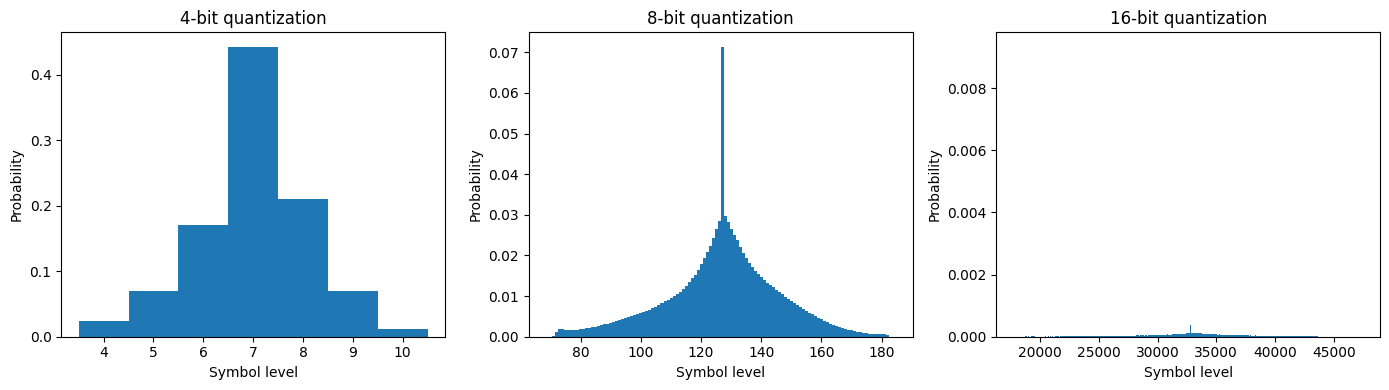

In [17]:
def get_probs(sym_list):
    n = len(sym_list)
    c = collections.Counter(sym_list)
    return {x: v/n for x,v in c.items()}

def entropy(prob_dict):
    return -sum(p*math.log2(p) for p in prob_dict.values() if p > 0)

probs_4  = get_probs(symbols_4bit)
probs_8  = get_probs(symbols_8bit)
probs_16 = get_probs(symbols_16bit)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, probs, bits in zip(axes, [probs_4, probs_8, probs_16], [4, 8, 16]):
    levels = sorted(probs.keys())
    ax.bar(levels, [probs[l] for l in levels], width=1.0)
    ax.set_title(f'{bits}-bit quantization')
    ax.set_xlabel('Symbol level')
    ax.set_ylabel('Probability')
plt.tight_layout()
plt.savefig('audio_distributions.png', dpi=100)
plt.show()

### Q1b: Plug-in entropy for each quantization

In [18]:
for bits, probs in [(4, probs_4), (8, probs_8), (16, probs_16)]:
    H = entropy(probs)
    H_max = bits
    print(f'{bits}-bit: H = {H:.4f} bits | H_max = {H_max} bits | ratio = {H/H_max:.3f}')

4-bit: H = 2.1688 bits | H_max = 4 bits | ratio = 0.542
8-bit: H = 6.1619 bits | H_max = 8 bits | ratio = 0.770
16-bit: H = 14.0548 bits | H_max = 16 bits | ratio = 0.878


### Q1c: Entropy vs sample size (8-bit)

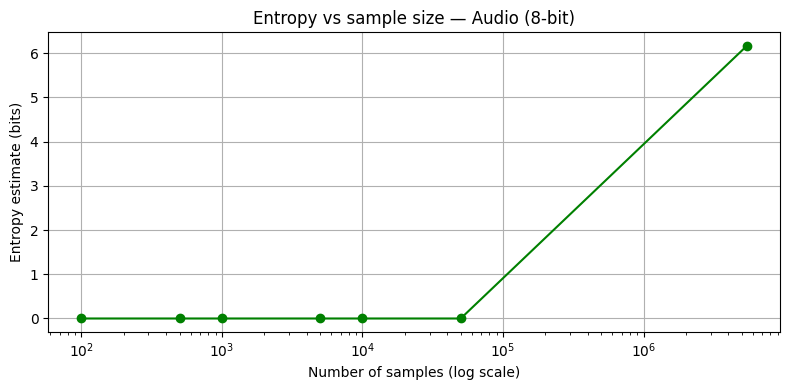

In [19]:
symbols = symbols_8bit
sample_sizes = [s for s in [100,500,1000,5000,10000,50000,len(symbols)] if s<=len(symbols)]
H_vs_n = [entropy(get_probs(symbols[:n_s])) for n_s in sample_sizes]

plt.figure(figsize=(8,4))
plt.semilogx(sample_sizes, H_vs_n, marker='o', color='green')
plt.xlabel('Number of samples (log scale)')
plt.ylabel('Entropy estimate (bits)')
plt.title('Entropy vs sample size — Audio (8-bit)')
plt.grid(True)
plt.tight_layout()
plt.savefig('audio_entropy_vs_n.png', dpi=100)
plt.show()

### Q1d: Miller-Madow bias correction

In [20]:
def entropy_mm(sym_list):
    n = len(sym_list)
    c = collections.Counter(sym_list)
    k = len(c)
    p = {x: v/n for x,v in c.items()}
    return entropy(p) + (k-1)/(2*n*math.log(2))

print('8-bit — plug-in vs Miller-Madow:')
for n_s in [1000, 5000, 10000, len(symbols)]:
    if n_s > len(symbols): continue
    sub = symbols[:n_s]
    h_p  = entropy(get_probs(sub))
    h_mm = entropy_mm(sub)
    print(f'  n={n_s:7d}: plug-in={h_p:.4f}, MM={h_mm:.4f}')

8-bit — plug-in vs Miller-Madow:
  n=   1000: plug-in=-0.0000, MM=0.0000
  n=   5000: plug-in=-0.0000, MM=0.0000
  n=  10000: plug-in=-0.0000, MM=0.0000
  n=5422080: plug-in=6.1619, MM=6.1619


---
## Task 2 — Joint and Conditional Entropy
### Q2a: Joint entropy H(Xt-1, Xt)

In [21]:
probs = probs_8
H_plugin = entropy(probs)

pairs = [(symbols[i], symbols[i+1]) for i in range(len(symbols)-1)]
H_joint = entropy(get_probs(pairs))

print(f'H(X)          = {H_plugin:.4f} bits')
print(f'H(Xt-1, Xt)   = {H_joint:.4f} bits')
print(f'2*H(X)        = {2*H_plugin:.4f} bits  (i.i.d. case)')
print(f'I(Xt-1; Xt)   = {2*H_plugin - H_joint:.4f} bits  (mutual information)')

H(X)          = 6.1619 bits
H(Xt-1, Xt)   = 9.0852 bits
2*H(X)        = 12.3237 bits  (i.i.d. case)
I(Xt-1; Xt)   = 3.2386 bits  (mutual information)


### Q2b: Conditional entropy H(Xt | Xt-1)

In [22]:
H_cond = H_joint - H_plugin
print(f'H(Xt | Xt-1) = {H_cond:.4f} bits')
print(f'Reduction from H(X): {H_plugin - H_cond:.4f} bits')
if H_cond < H_plugin:
    print('Audio has strong temporal correlations — expected for natural sound.')

H(Xt | Xt-1) = 2.9233 bits
Reduction from H(X): 3.2386 bits
Audio has strong temporal correlations — expected for natural sound.


### Q2c: Effect of quantization resolution

In [23]:
print('Quantization resolution vs conditional entropy:')
for bits, syms in [(4, symbols_4bit), (8, symbols_8bit), (16, symbols_16bit)]:
    p = get_probs(syms)
    h = entropy(p)
    ps = [(syms[i], syms[i+1]) for i in range(len(syms)-1)]
    hj = entropy(get_probs(ps))
    hc = hj - h
    print(f'  {bits}-bit: H(X)={h:.3f}, H(Xt|Xt-1)={hc:.3f}')

Quantization resolution vs conditional entropy:
  4-bit: H(X)=2.169, H(Xt|Xt-1)=0.470
  8-bit: H(X)=6.162, H(Xt|Xt-1)=2.923
  16-bit: H(X)=14.055, H(Xt|Xt-1)=7.622


---
## Task 3 — Entropy Rate Estimation
### Q3a: Block-entropy method

In [24]:
def block_entropy_rate(seq, block_len):
    blocks = [tuple(seq[i:i+block_len]) for i in range(0, len(seq)-block_len+1, block_len)]
    if len(blocks) < 10: return None
    c = collections.Counter(blocks)
    p = {b: v/len(blocks) for b,v in c.items()}
    return entropy(p) / block_len

print('Block-entropy method (8-bit):')
block_results = []
for bl in [1,2,3,4]:
    hr = block_entropy_rate(symbols, bl)
    if hr:
        block_results.append((bl, hr))
        print(f'  Block {bl}: {hr:.4f} bits/sample')

Block-entropy method (8-bit):
  Block 1: 6.1619 bits/sample
  Block 2: 4.5422 bits/sample
  Block 3: 3.7403 bits/sample
  Block 4: 3.2895 bits/sample


### Q3b: Conditional-entropy method

In [25]:
def cond_entropy_rate(seq, k):
    ctx_next = collections.Counter()
    ctx_cnt  = collections.Counter()
    for i in range(k, len(seq)):
        ctx = tuple(seq[i-k:i])
        ctx_next[(ctx, seq[i])] += 1
        ctx_cnt[ctx] += 1
    total = sum(ctx_cnt.values())
    H = 0.0
    for ctx, cnt in ctx_cnt.items():
        p_ctx = cnt / total
        h_c = 0.0
        for sym in set(seq[:500]):
            c = ctx_next.get((ctx, sym), 0)
            if c > 0:
                p = c / cnt
                h_c -= p * math.log2(p)
        H += p_ctx * h_c
    return H

print('Conditional-entropy method (8-bit):')
cond_results = [(0, H_plugin)]
print(f'  Context 0: {H_plugin:.4f} bits/sample')
for k in [1, 2]:
    hr = cond_entropy_rate(symbols, k)
    cond_results.append((k, hr))
    print(f'  Context {k}: {hr:.4f} bits/sample')

Conditional-entropy method (8-bit):
  Context 0: 6.1619 bits/sample
  Context 1: 0.0877 bits/sample
  Context 2: 0.0618 bits/sample


### Q3c: Plot entropy rate estimates

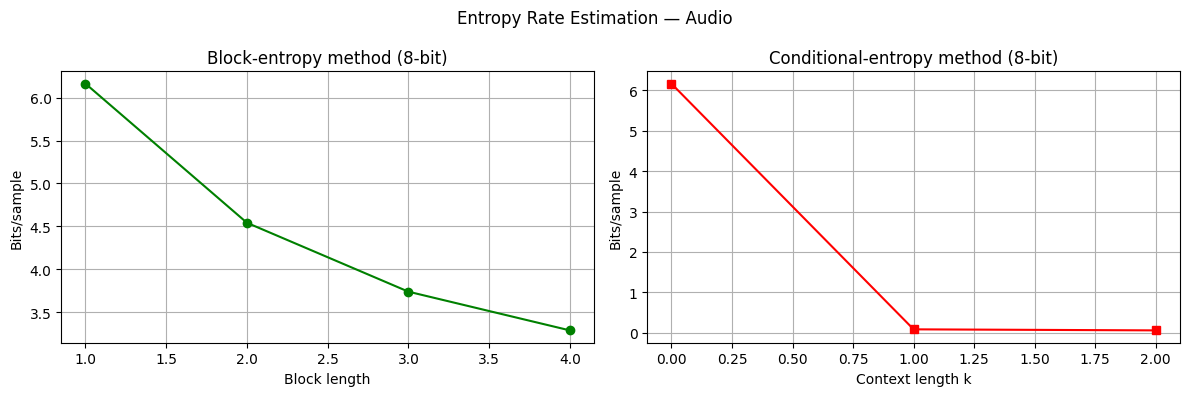

Both methods decrease with longer blocks/context — temporal correlation captured.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot([x[0] for x in block_results], [x[1] for x in block_results], marker='o', color='green')
axes[0].set_xlabel('Block length')
axes[0].set_ylabel('Bits/sample')
axes[0].set_title('Block-entropy method (8-bit)')
axes[0].grid(True)

axes[1].plot([x[0] for x in cond_results], [x[1] for x in cond_results], marker='s', color='red')
axes[1].set_xlabel('Context length k')
axes[1].set_ylabel('Bits/sample')
axes[1].set_title('Conditional-entropy method (8-bit)')
axes[1].grid(True)

plt.suptitle('Entropy Rate Estimation — Audio')
plt.tight_layout()
plt.savefig('audio_entropy_rate.png', dpi=100)
plt.show()
print('Both methods decrease with longer blocks/context — temporal correlation captured.')